# RSI Ratio & Regime Visualizer
# Exploring: RSI(3) / RSI(14) Ratio with 55-WMA Regime Filter
# max stocks: 5
# Price Bracket: 90- 600
# max year: 3 (approx 750 trading days)

In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
display(HTML("<style>.container { width:100% !important; }</style>"))
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading & Calculations
def calc_rsi(series, period):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calc_wma(series, period):
    weights = np.arange(1, period + 1)
    return series.rolling(period).apply(lambda prices: np.dot(prices, weights) / weights.sum(), raw=True)

all_data = []
files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
random.seed(42) 
random.shuffle(files)

loaded = 0
for file_path in files:
    if loaded >= 5: 
        break
    symbol = os.path.basename(file_path).replace('.csv', '')
    try:
        df = pd.read_csv(file_path).dropna(subset=['Close'])
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        
        # We need approx 275 days (55 weeks * 5 days) for the 55-WMA
        if len(df) < 1100: 
            continue
            
        latest_price = df['Close'].iloc[-1]
        if not (90 <= latest_price <= 600):
            continue
            
        # Indicators
        # 55-WMA on weekly is roughly 275 days on daily data
        df['WMA_55_Weekly_Approx'] = calc_wma(df['Close'], 275)
        
        df['RSI_3'] = calc_rsi(df['Close'], 3)
        df['RSI_14'] = calc_rsi(df['Close'], 14)
        
        # Calculate the Ratio: RSI(3) / RSI(14)
        # Add a tiny number to denominator to avoid division by zero
        df['RSI_Ratio'] = df['RSI_3'] / (df['RSI_14'] + 0.0001)
        
        # Keep only the last 3 years (750 days) for clean plotting
        df = df.tail(750).reset_index(drop=True)
        
        df['Symbol'] = symbol
        all_data.append(df)
        loaded += 1
    except Exception as e:
        pass

data = pd.concat(all_data, ignore_index=True)
print(f"Loaded {len(data['Symbol'].unique())} stocks for Ratio analysis.")


Loaded 5 stocks for Ratio analysis.


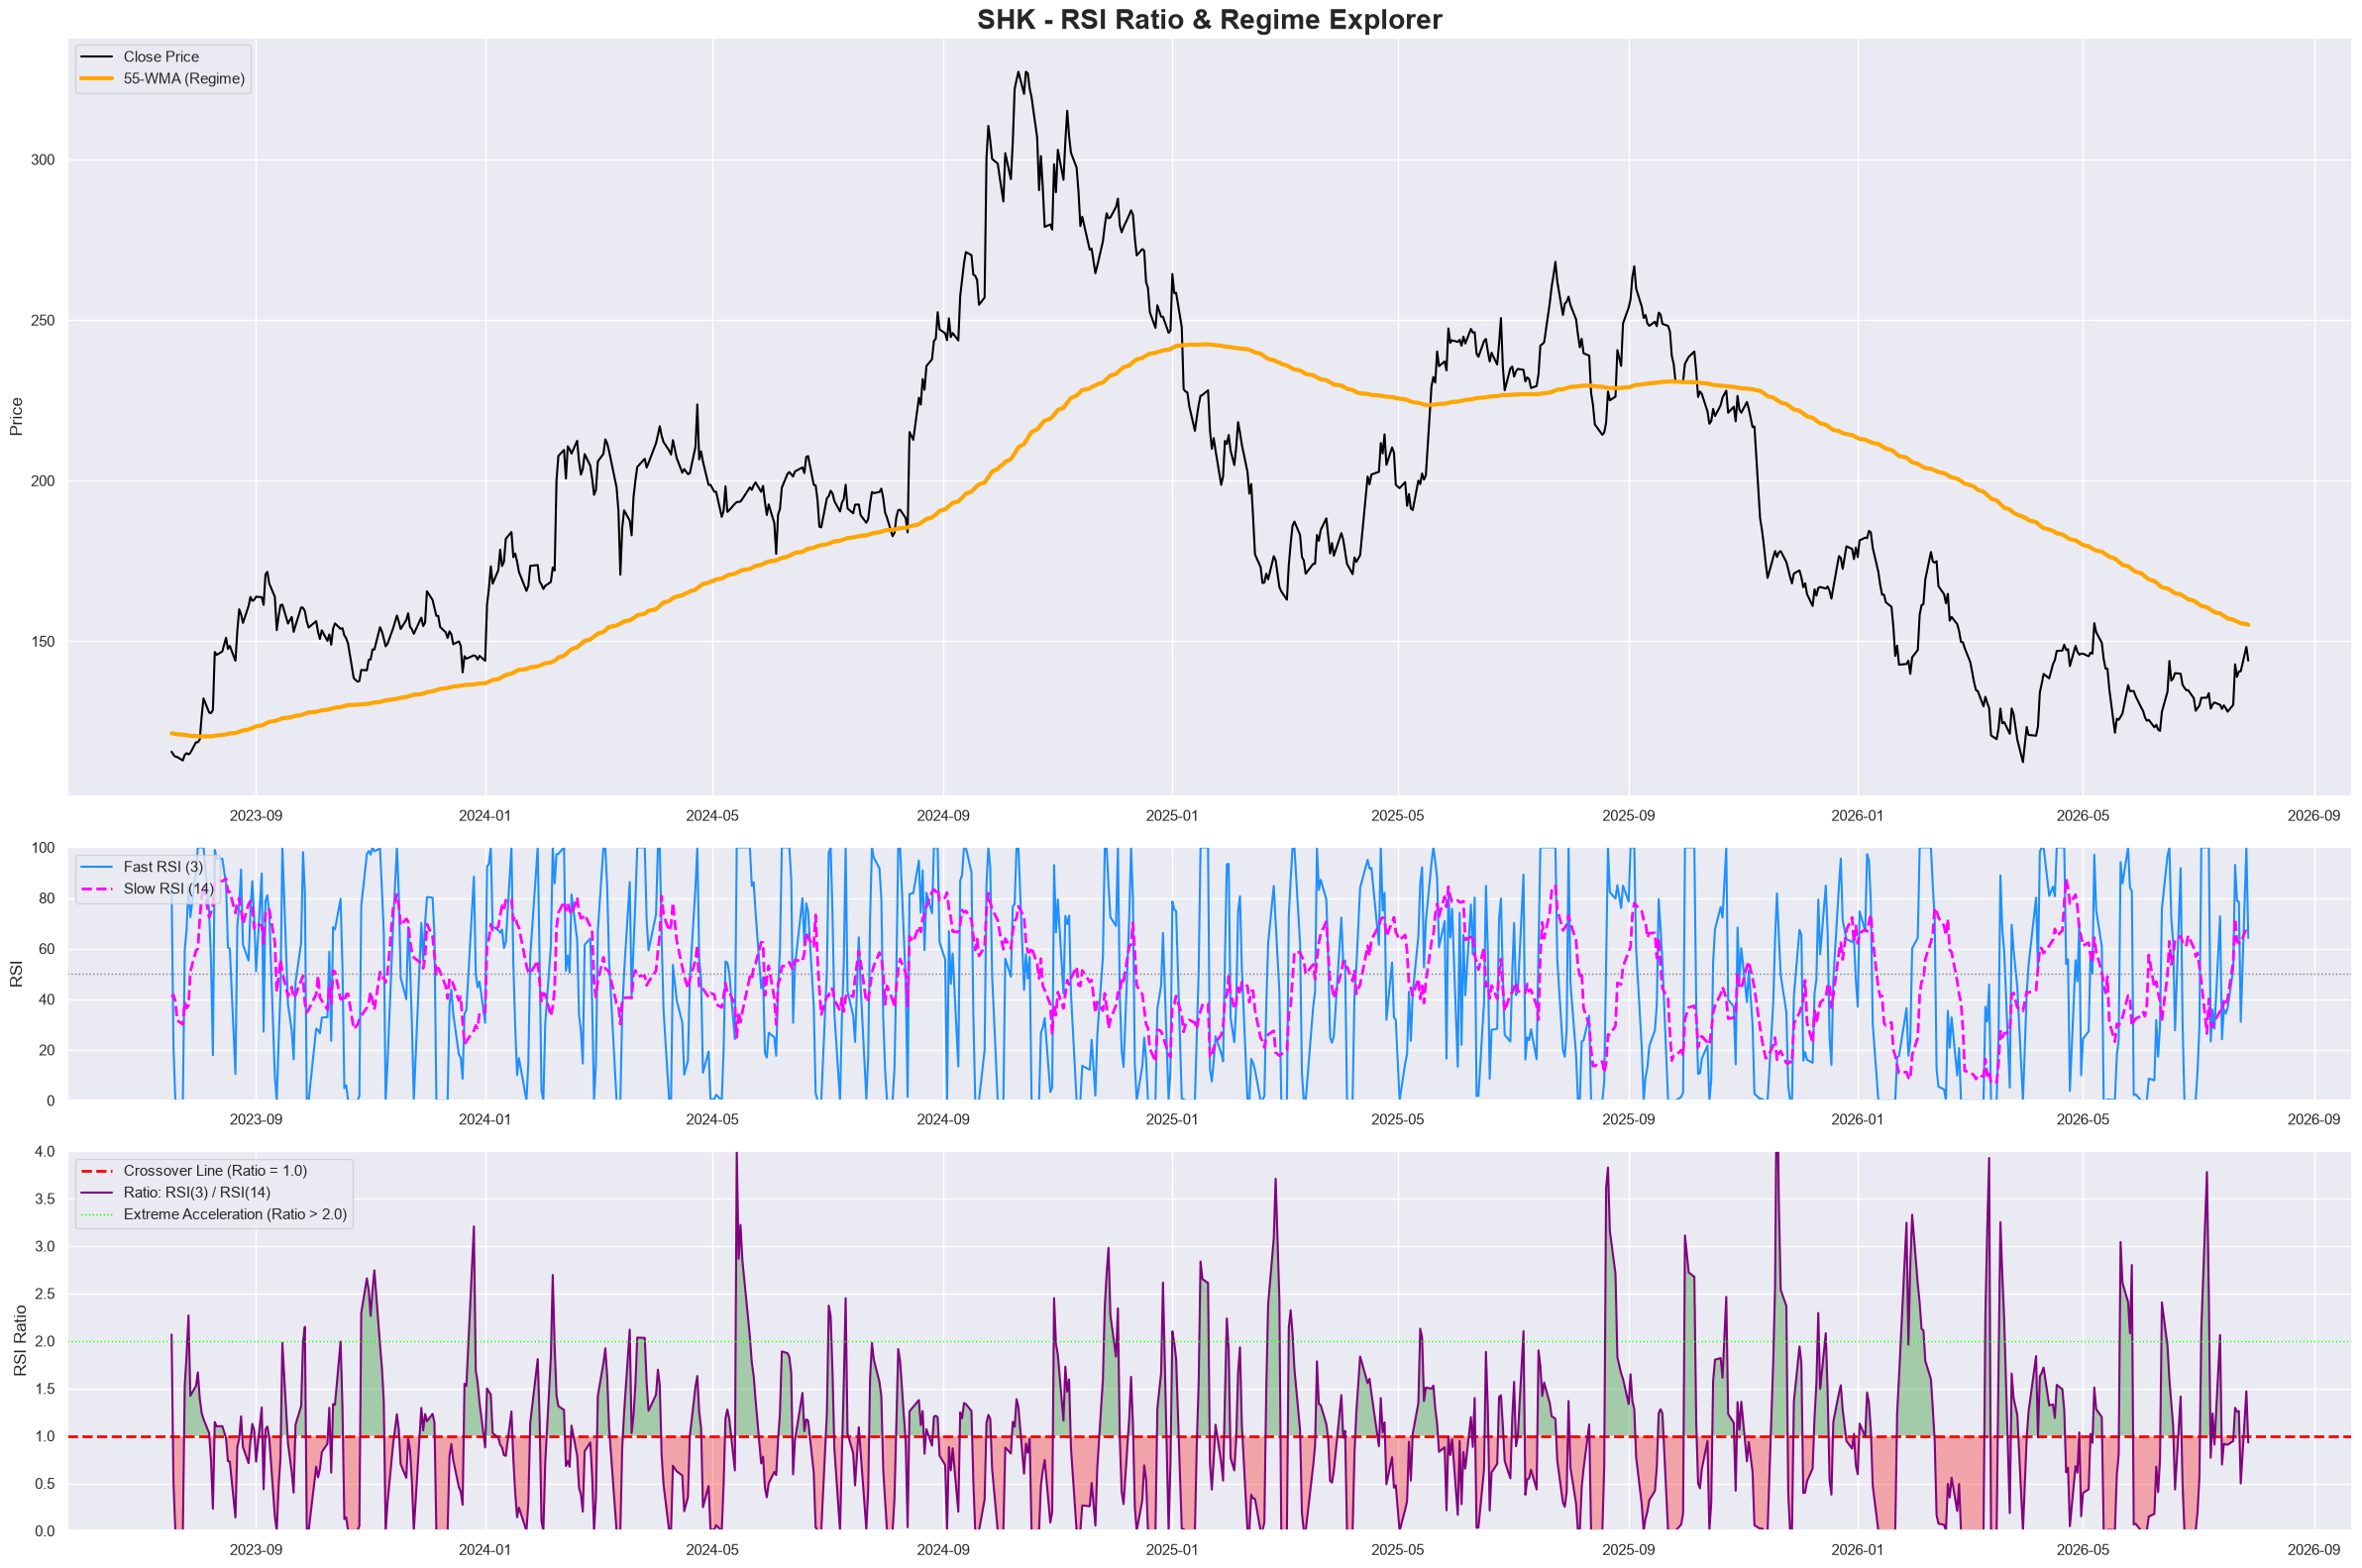

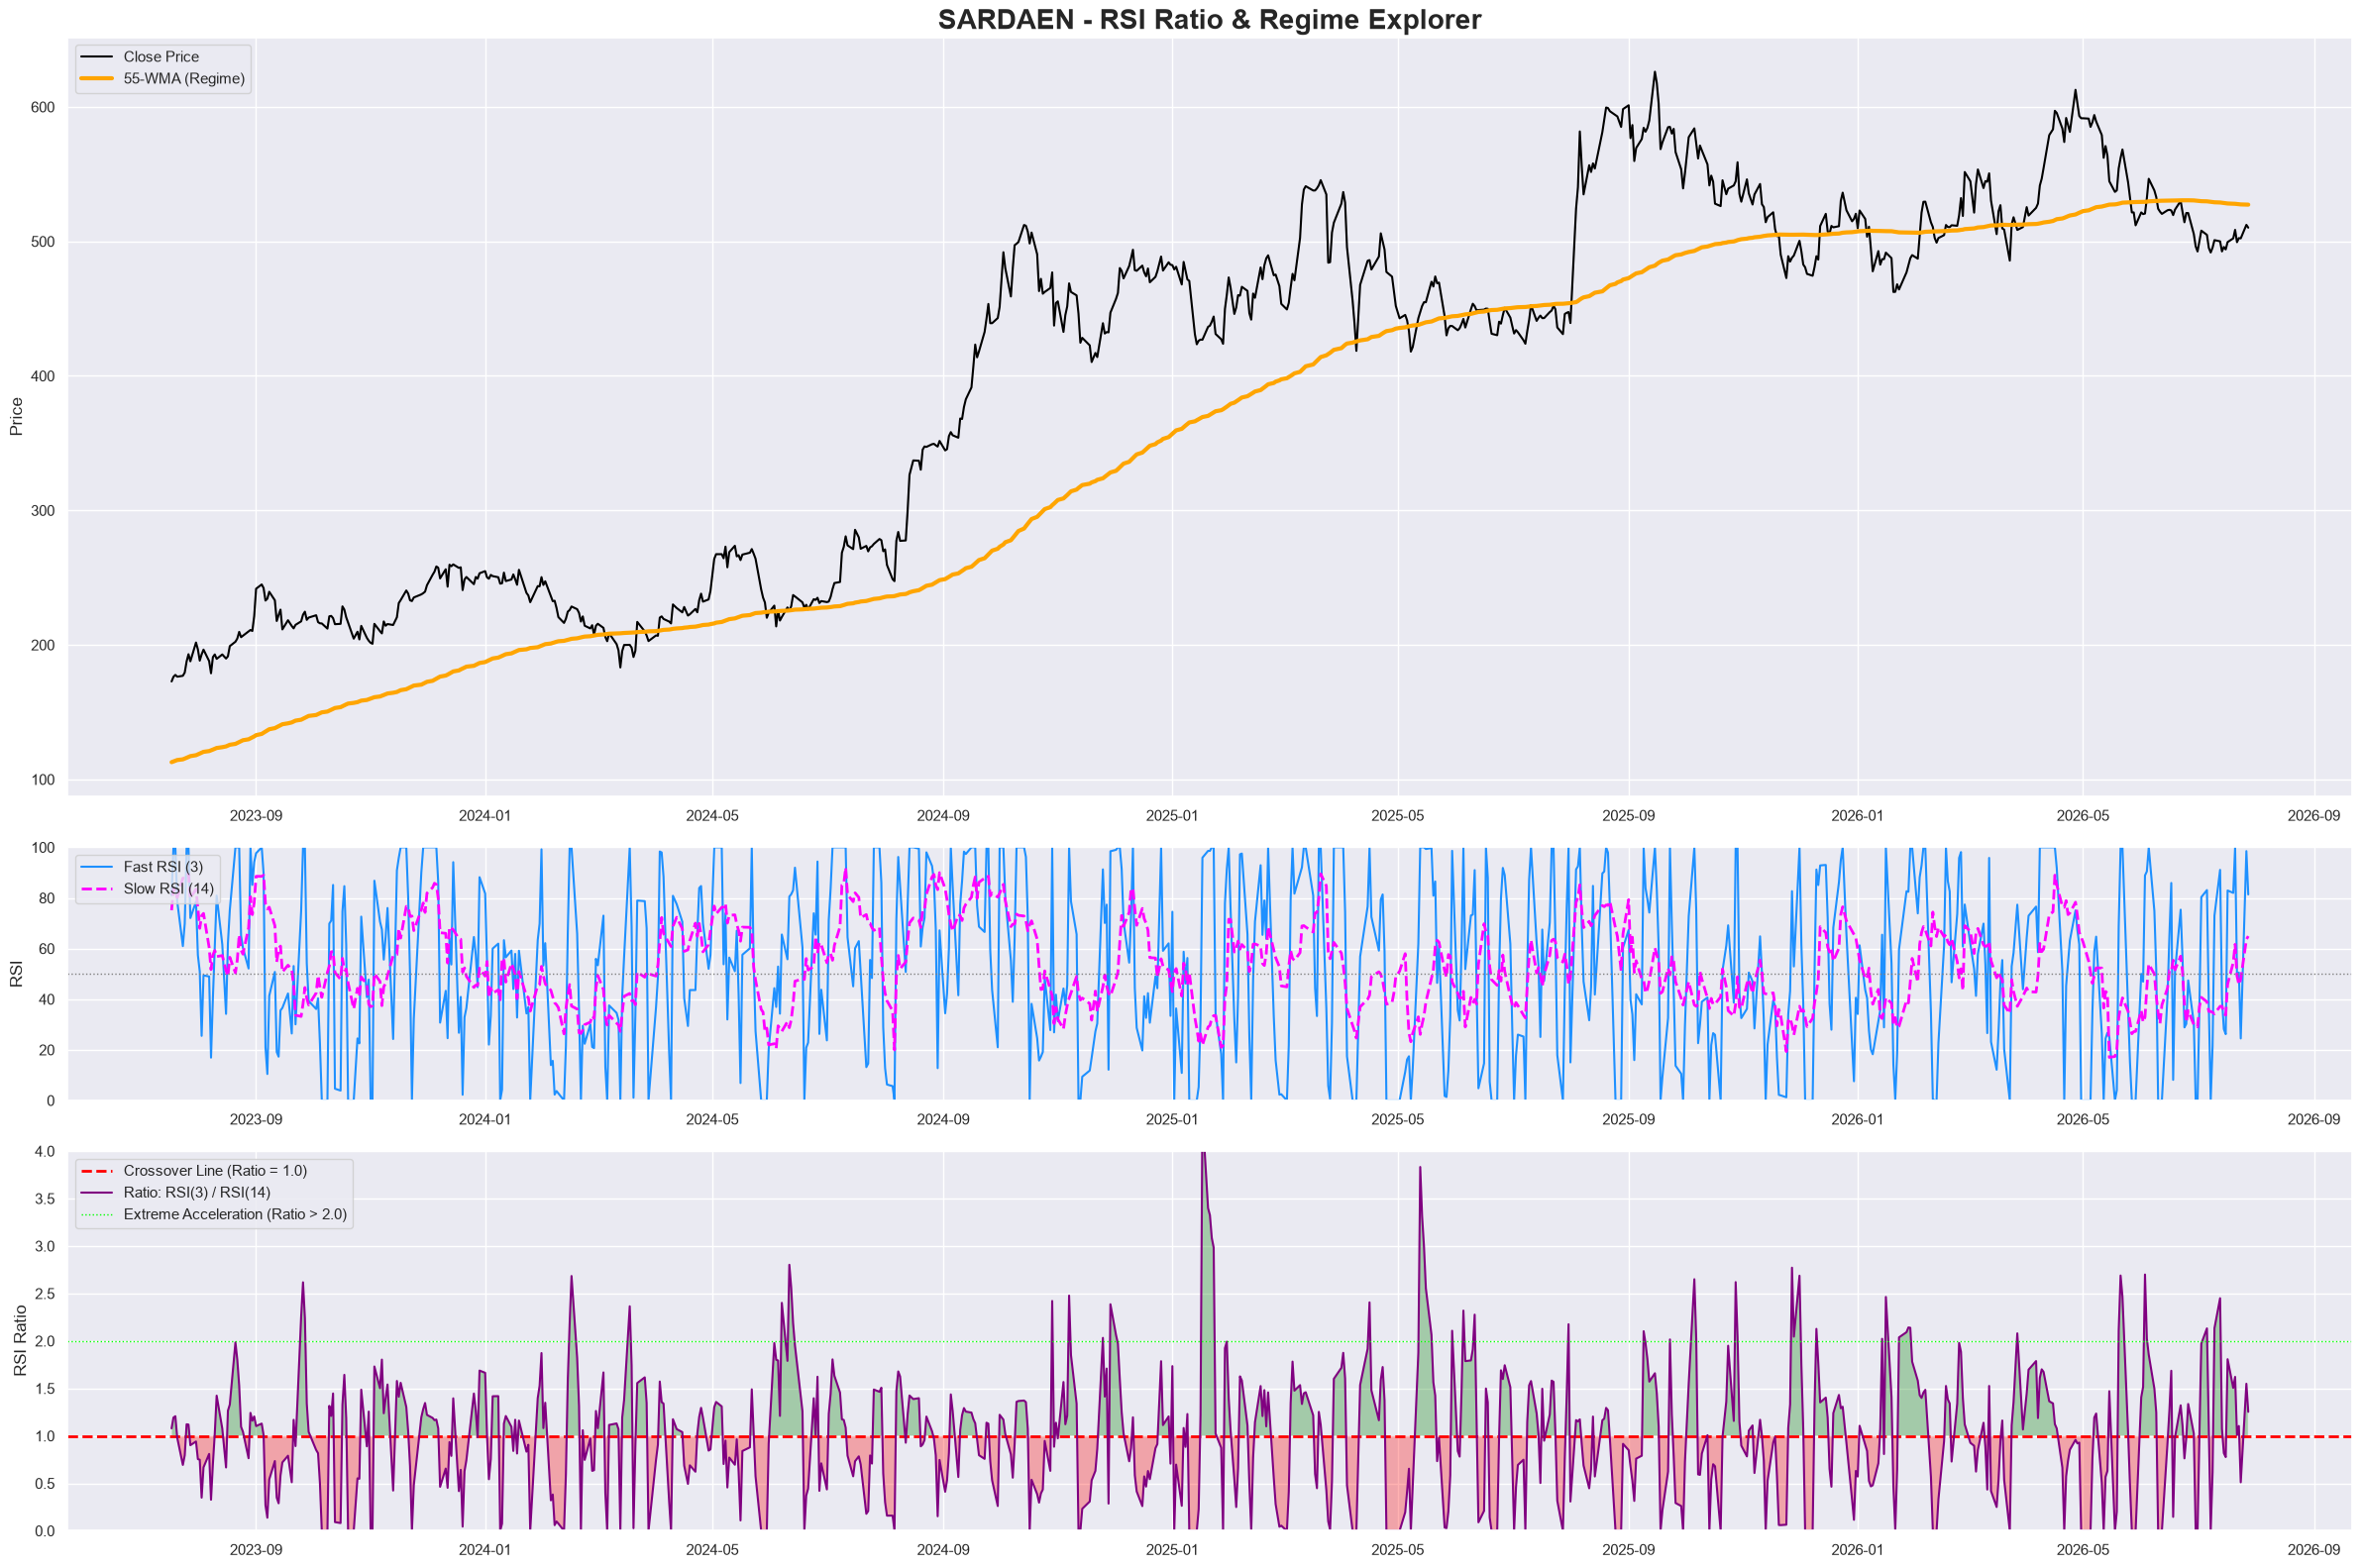

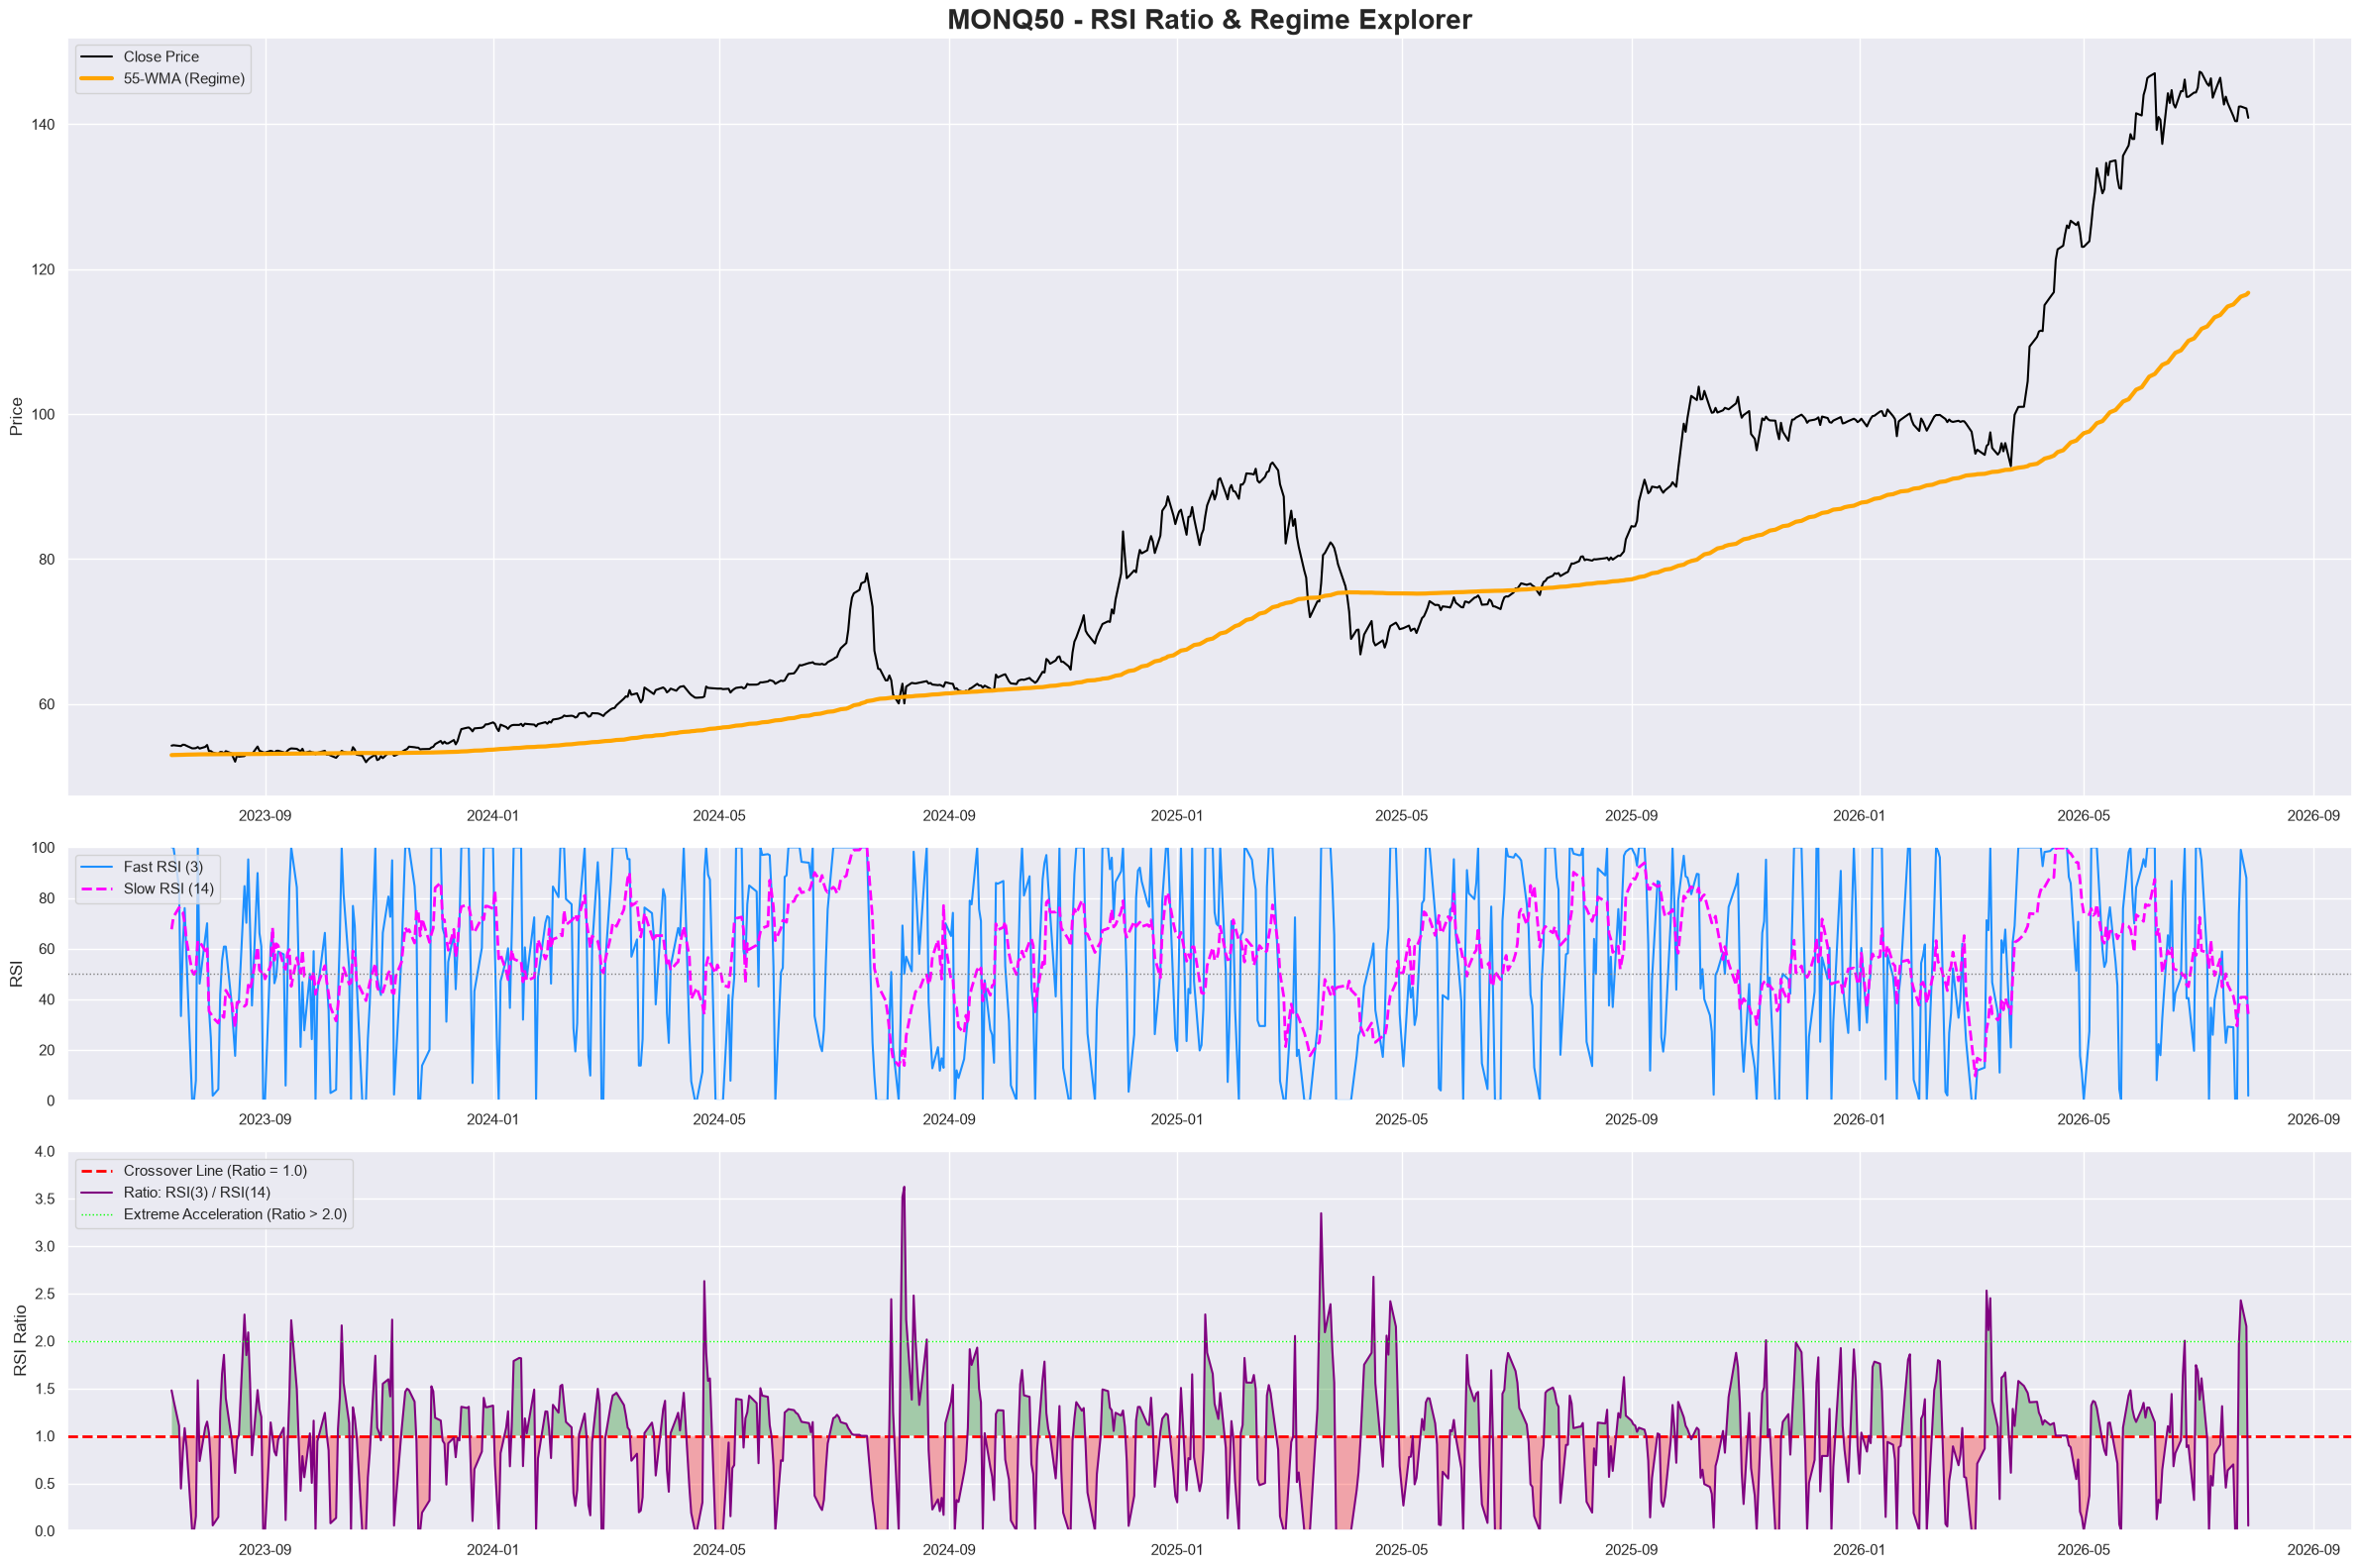

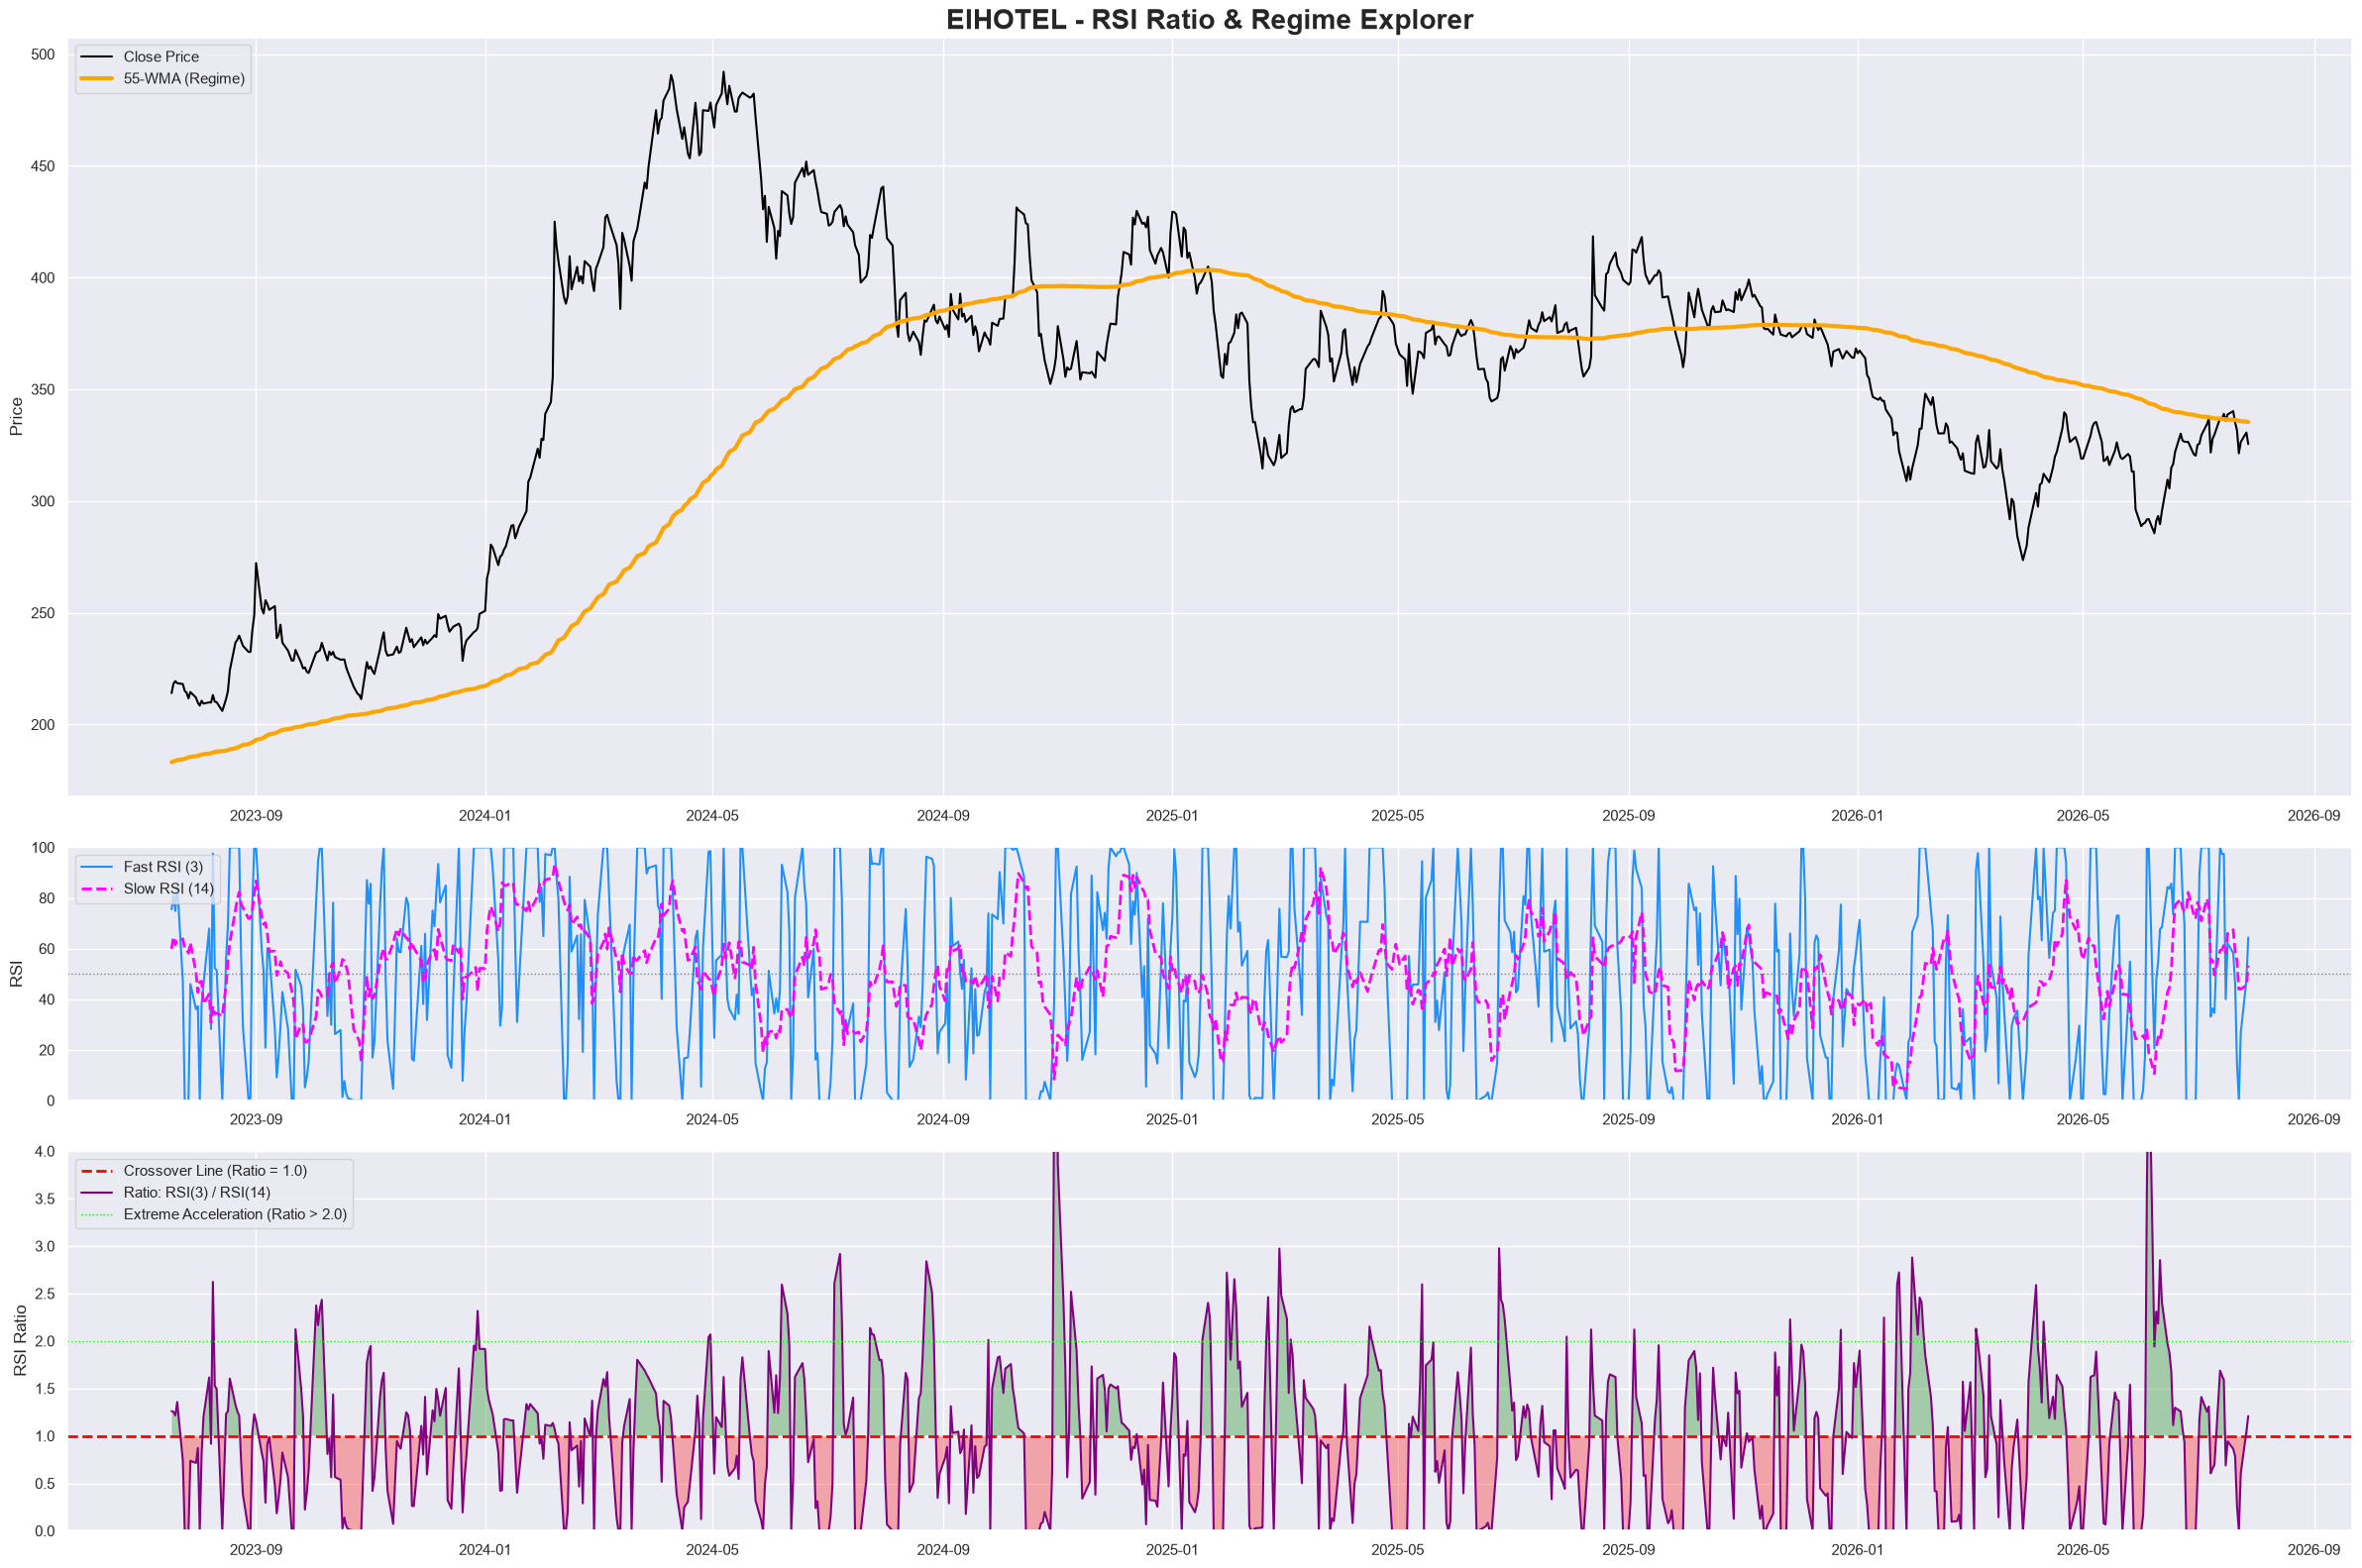

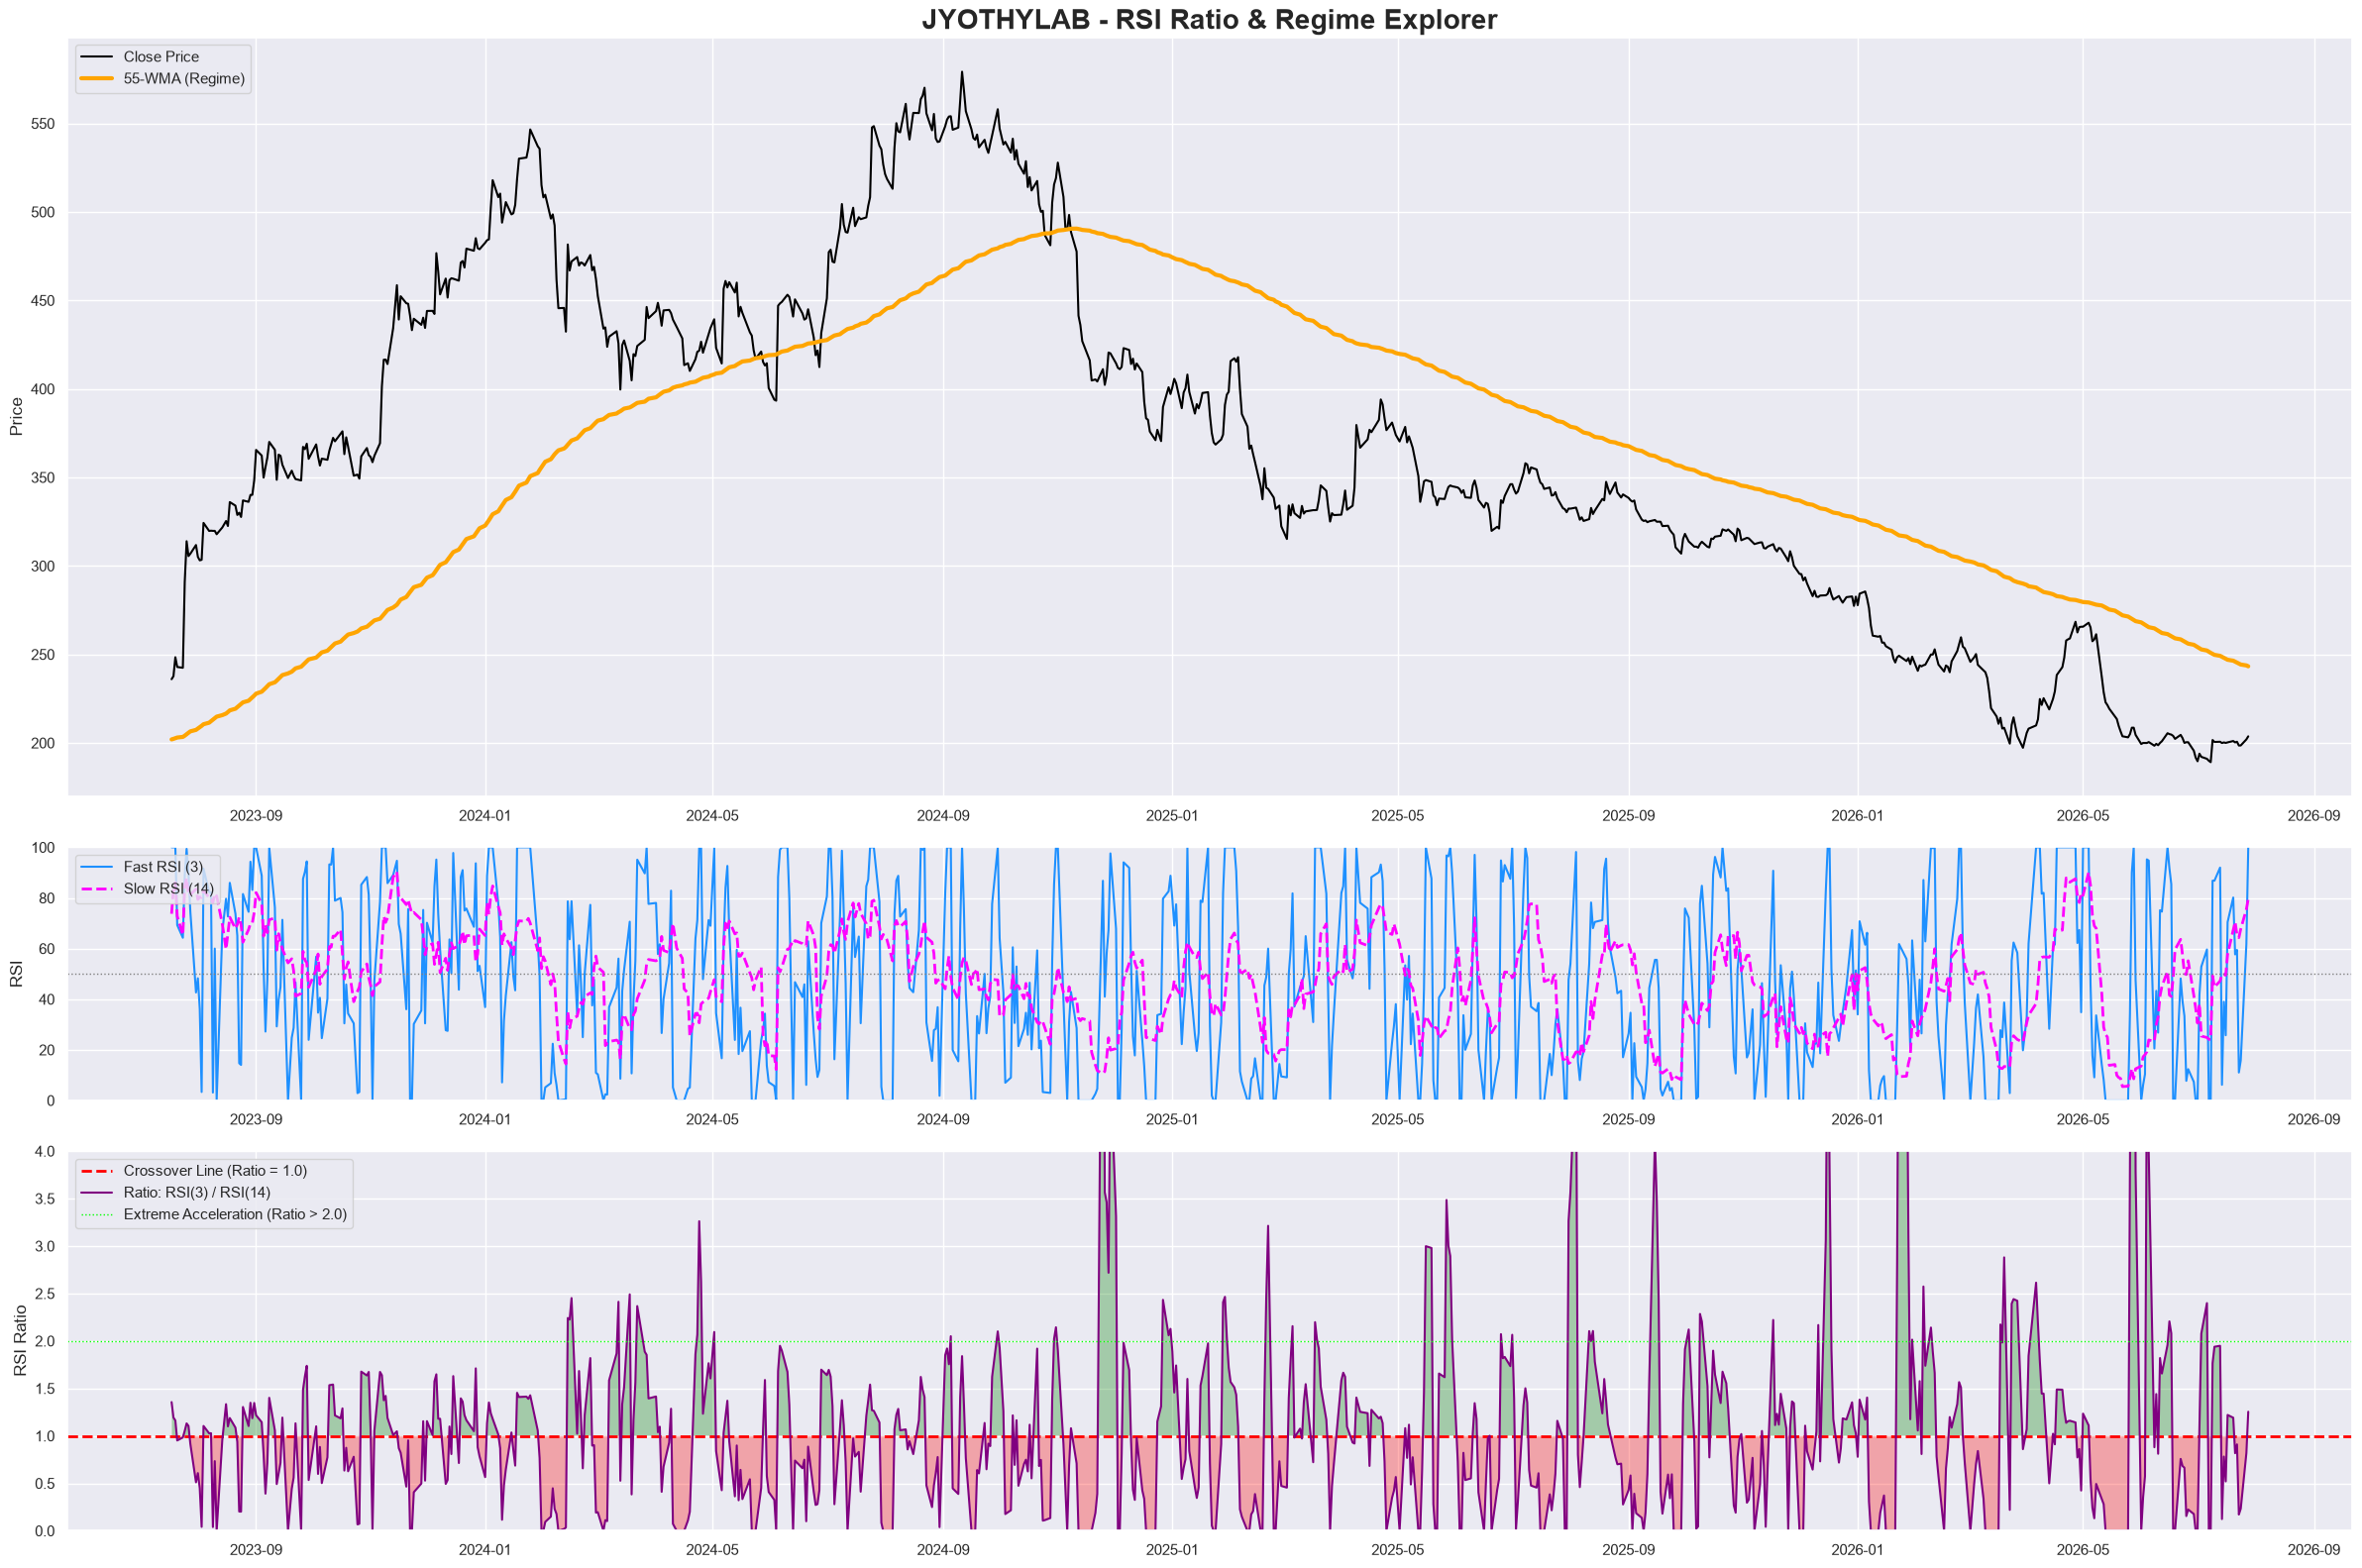

In [3]:
# 3. Visualizing the Ratio and Regime
symbols = data['Symbol'].unique()

for symbol in symbols:
    df = data[data['Symbol'] == symbol].reset_index(drop=True)
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(24, 16), gridspec_kw={'height_ratios': [3, 1, 1.5]})
    
    # --- Top Plot: Price & 55-WMA Regime ---
    ax1.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1.5)
    
    # Plot 55-WMA with color changing based on slope (Trend Regime)
    wma = df['WMA_55_Weekly_Approx']
    ax1.plot(df['Date'], wma, label='55-WMA (Regime)', color='orange', linewidth=3)
    
    ax1.set_title(f"{symbol} - RSI Ratio & Regime Explorer", fontsize=20, fontweight='bold')
    ax1.set_ylabel('Price')
    ax1.legend(loc='upper left')
    
    # --- Middle Plot: RSI(3) and RSI(14) ---
    ax2.plot(df['Date'], df['RSI_3'], label='Fast RSI (3)', color='dodgerblue', linewidth=1.5)
    ax2.plot(df['Date'], df['RSI_14'], label='Slow RSI (14)', color='magenta', linewidth=2, linestyle='--')
    ax2.axhline(50, color='gray', linewidth=1, linestyle=':')
    ax2.set_ylabel('RSI')
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper left')
    
    # --- Bottom Plot: RSI Ratio ---
    # The baseline is 1.0 (where RSI3 = RSI14)
    ax3.axhline(1.0, color='red', linewidth=2, linestyle='--', label='Crossover Line (Ratio = 1.0)')
    ax3.plot(df['Date'], df['RSI_Ratio'], label='Ratio: RSI(3) / RSI(14)', color='purple', linewidth=1.5)
    
    # Fill color: Green when > 1 (Fast Momentum Dominating), Red when < 1 (Fast Momentum Lagging)
    ax3.fill_between(df['Date'], df['RSI_Ratio'], 1.0, where=(df['RSI_Ratio'] >= 1.0), facecolor='green', alpha=0.3, interpolate=True)
    ax3.fill_between(df['Date'], df['RSI_Ratio'], 1.0, where=(df['RSI_Ratio'] < 1.0), facecolor='red', alpha=0.3, interpolate=True)
    
    # Highlight explosive ratio spikes (e.g., Ratio > 2.0)
    ax3.axhline(2.0, color='lime', linewidth=1, linestyle=':', label='Extreme Acceleration (Ratio > 2.0)')
    
    ax3.set_ylabel('RSI Ratio')
    ax3.set_ylim(0, 4) # Cap the y-axis to make it readable, ratios rarely exceed 4
    ax3.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()
